# DeepLOB 注释版：先看数据集

## 1. 数据集背景

本 notebook 使用的是 **FI-2010** 限价订单簿（Limit Order Book, LOB）基准数据集，并参照论文 *DeepLOB: Deep Convolutional Neural Networks for Limit Order Books* 的实验设置。

- 任务目标：预测中间价（mid-price）未来方向
- 任务形式：三分类（上涨 / 平稳 / 下跌）
- 数据特点：高频、事件驱动、强时序依赖、类别分布可能不均衡

## 2. 文件组织与切分（对应当前项目）

当前目录中的典型文件包括：

- `Train_Dst_NoAuction_DecPre_CF_7.txt`（训练）
- `Test_Dst_NoAuction_DecPre_CF_7.txt`、`Test_Dst_NoAuction_DecPre_CF_8.txt`、`Test_Dst_NoAuction_DecPre_CF_9.txt`（测试）

在 DeepLOB 的常见处理流程中：

- 训练文件再按时间切一部分做验证集（例如 80/20）
- 多个测试文件按时间拼接为完整测试集
- 每个时间点（event）对应一列数据

## 3. 每个 txt 的 149 维结构（按你给的维度拆解）

这些 txt 通常是“**按行存特征**、**按列存时间事件**”的矩阵，而不是“每行一个样本”。

### 3.1 输入前 40 维（0~39）：raw LOB

对任意一个 event（txt 的某一列），前 40 维来自前 10 档盘口，每档 4 个值：

- 第 l 档（`l=1...10`）: `ask_price_l, ask_size_l, bid_price_l, bid_size_l`

展开顺序通常是：

`[ask_p1, ask_v1, bid_p1, bid_v1, ask_p2, ask_v2, bid_p2, bid_v2, ..., ask_p10, ask_v10, bid_p10, bid_v10]`

简化样例（只展示前 3 档，实际到 10 档）：

- 第 1 档：卖一价 101.20，卖一量 800，买一价 101.18，买一量 950
- 第 2 档：卖二价 101.22，卖二量 760，买二价 101.16，买二量 880
- 第 3 档：卖三价 101.24，卖三量 640，买三价 101.14，买三量 920

该 event 的前 12 维就是：

`[101.20, 800, 101.18, 950, 101.22, 760, 101.16, 880, 101.24, 640, 101.14, 920, ...]`

按 0-based 索引理解：

- 0~3: level-1 的 `[ask_p1, ask_v1, bid_p1, bid_v1]`
- 4~7: level-2 的 `[ask_p2, ask_v2, bid_p2, bid_v2]`
- ...
- 36~39: level-10 的 `[ask_p10, ask_v10, bid_p10, bid_v10]`

### 3.2 其他维度（40~143）：handcrafted features

这 104 维是基于 LOB 原始价量进一步构造的手工统计特征，通常用于传统机器学习基线。常见类别包括：

- 价差与价差变化
- 各档深度、累积深度与不平衡度（imbalance）
- 跨档价差、斜率、梯度
- 简单收益率/差分等短期动态统计

你可以把它理解成“研究者先验设计的摘要信号”。在 DeepLOB 主设定里，这部分保留在文件中，但模型输入通常不使用它们。

### 3.3 最后 5 行（144~148）：labels

最后 5 维是 5 个不同预测 horizon 的三分类标签（上涨/平稳/下跌）。

- 原始标签常见取值：`{1, 2, 3}`
- 训练时常映射为：`{0, 1, 2}`
- 第 k 个 horizon 的标签通常取 `y[:, k]`

因此，如果原矩阵记为 `data`（形状 `(149, N)`）：

- raw LOB 输入: `data[:40, :].T`，形状 `(N, 40)`
- handcrafted: `data[40:144, :].T`，形状 `(N, 104)`
- 5 个标签: `data[144:149, :].T`，形状 `(N, 5)`

### 3.3 补充：标签对应“未来多少个 event”

可以。FI-2010 常见定义里，最后 5 行标签对应 5 个预测跨度（horizon）：

- 第 1 个标签：未来 `10` 个 event
- 第 2 个标签：未来 `20` 个 event
- 第 3 个标签：未来 `30` 个 event
- 第 4 个标签：未来 `50` 个 event
- 第 5 个标签：未来 `100` 个 event

如果按 0-based 索引记为 `k=0..4`，通常对应：

- `k=0 -> 10 events`
- `k=1 -> 20 events`
- `k=2 -> 30 events`
- `k=3 -> 50 events`
- `k=4 -> 100 events`

在你的训练代码里如果用 `k=4`，就是在预测“未来 100 个 event 后”的中间价方向类别。

标签本质上不是“未来单点价格涨跌”，而是基于 horizon 内中间价变化（常配合平滑/阈值）得到的三分类：

- `1`：下跌
- `2`：平稳
- `3`：上涨

训练前再映射为 `{0,1,2}`。

## 4. 从“时间点”到“模型样本”

DeepLOB 不直接用单个时间点，而是用长度为 `T` 的滑动窗口构造样本：

- 单样本输入形状：`(T, 40)`
- 若总事件数为 `N`，可构造样本数约为 `N - T + 1`
- 某个 horizon 的标签由参数 `k` 选择（`k in [0,1,2,3,4]`）

例如 `T=100` 时，每个样本使用最近 100 个 event 的盘口序列来预测未来方向。

## 5. 为什么这个数据表示适合 DeepLOB

DeepLOB 的网络结构（CNN + Inception + LSTM）对应三类模式：

- CNN：提取盘口局部结构与价量交互模式
- Inception：并行感受野建模不同时间尺度
- LSTM：建模更长时间依赖

也就是说，数据的核心不是“静态特征”，而是“短中期连续演化轨迹”。

---

## 6. FI-2010 / DeepLOB 数据完整链路（原始来源 -> 149维 -> (num_samples, 100, 40)）

下面按你关心的 6 个问题给出完整链路。

### 6.1 原始交易所数据从哪里来

FI-2010 并不是“人工合成数据”，而是来自真实证券交易所的高频限价订单簿（Level-2）记录。论文作者将原始市场逐笔数据（订单提交、撤单、成交等）做标准化和脱敏处理后，发布为机器学习可直接使用的基准数据。

可理解为：

- 交易所原始 feed（订单簿状态 + 事件流）
- -> 学术数据清洗、对齐、归一化
- -> 形成 FI-2010 的统一矩阵格式

### 6.2 什么是 LOB event

在该数据里，event 指“会导致订单簿状态变化的一次市场事件”，例如：

- 新限价单进入某档位
- 某档挂单被撤销
- 市价单/可成交订单导致某档成交并更新深度

关键点：

- event 是不等间隔时间的（事件驱动），不是固定 1 秒/1 分钟采样
- 每发生一个 event，就得到一个新的订单簿快照
- 在 txt 中，通常“一列 = 一个 event 时刻的特征与标签”

### 6.3 数据如何加工（从原始 order flow 到学习样本）

典型加工流程：

1. 从原始撮合流重建每个 event 后的 LOB 前若干档（这里是前 10 档）。
2. 计算原始 LOB 特征（价格与数量）。
3. 构造一组 handcrafted features（手工统计特征）。
4. 根据未来 horizon 的中间价变化构造分类标签（上涨/平稳/下跌）。
5. 做归一化（你当前文件名中的 `DecPre` 即 decimal precision 方案）。
6. 按统一格式写为矩阵 txt，方便不同模型复现实验。

### 6.4 149 维是怎么得到的

你给的索引划分是正确的：

- 0~39: raw LOB（40维）
- 40~143: handcrafted features（104维）
- 144~148: labels（5维）

总维度：

$$40 + 104 + 5 = 149$$

所以每个 event 列向量长度是 149。把所有 event 按时间并列后，就得到形状为 `(149, N)` 的矩阵（N 是该文件的事件总数）。

### 6.5 DeepLOB 为什么只用 40 维

DeepLOB 论文强调端到端从原始 LOB 学习表征，因此仅使用前 40 维 raw LOB，主要原因有：

- 避免依赖人工特征工程，增强方法通用性
- 让 CNN/Inception/LSTM 自己从价量序列中抽取模式
- 降低输入冗余与特征共线性风险
- 与传统“手工特征 + 浅层模型”形成清晰对比

因此在代码中会看到：

- `X = data[:40, :].T`
- handcrafted 104 维被保留在原文件，但在 DeepLOB 主实验中不作为输入

### 6.6 最终如何变成 (num_samples, 100, 40)

以 `T=100` 为例，过程如下：

1. 先把前 40 行转置，得到 `X_event`，形状 `(N, 40)`。
2. 用滑动窗口构造序列样本：第 i 个样本取 `X_event[i:i+100]`。
3. 每个样本就是一个二维张量 `(100, 40)`。
4. 共可得到 `num_samples = N - 100 + 1` 个样本。
5. 堆叠后得到：`(num_samples, 100, 40)`。
6. 若送入 2D-CNN，通常再加 channel 维，成为 `(num_samples, 1, 100, 40)`。

标签对齐方式：

- 先取 5 个 horizon 标签矩阵 `(N, 5)`
- 与窗口末端对齐后，得到 `(num_samples, 5)`
- 选择某个 `k`（例如 `k=4`）作为当前训练目标，得到 `(num_samples,)`
- 再把标签值从 {1,2,3} 映射到 {0,1,2}

---

下面的代码单元将按上述约定加载 txt、构造滑动窗口样本，并进入模型训练与评估。

In [1]:
import numpy as np
import torch
from torch.utils import data


# -----------------------------
# 1. 特征与标签提取
# -----------------------------
def prepare_x(raw_data):
    """提取前 40 行 raw LOB 特征，并转置为 (N, 40)。"""
    return raw_data[:40, :].T


def get_label(raw_data):
    """提取最后 5 行标签，并转置为 (N, 5)。"""
    return raw_data[-5:, :].T


# -----------------------------
# 2. 滑动窗口样本构造
# -----------------------------
def build_sequence_samples(features, labels, window_size):
    """将逐时刻特征切成长度为 window_size 的序列样本。"""
    num_events, feature_dim = features.shape
    num_samples = num_events - window_size + 1

    sample_x = np.zeros((num_samples, window_size, feature_dim))
    sample_y = labels[window_size - 1:num_events]

    for idx in range(window_size, num_events + 1):
        sample_x[idx - window_size] = features[idx - window_size:idx, :]

    return sample_x, sample_y


# -----------------------------
# 3. PyTorch 数据集
# -----------------------------
class DeepLOBDataset(data.Dataset):
    """DeepLOB 的 PyTorch Dataset，输出形状为 (1, T, 40)。"""

    def __init__(self, raw_data, horizon_index=4, num_classes=3, window_size=100):
        self.horizon_index = horizon_index
        self.num_classes = num_classes
        self.window_size = window_size

        features = prepare_x(raw_data)
        labels = get_label(raw_data)
        features, labels = build_sequence_samples(features, labels, window_size)

        # 将标签从 {1, 2, 3} 映射到 {0, 1, 2}
        labels = labels[:, horizon_index] - 1

        self.x = torch.from_numpy(features).unsqueeze(1).float()
        self.y = torch.from_numpy(labels).long()
        self.length = len(self.x)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        return self.x[index], self.y[index]


# -----------------------------
# 4. 读取原始 txt 文件
# -----------------------------
train_raw = np.loadtxt('Train_Dst_NoAuction_DecPre_CF_7.txt')
test_raw_7 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_7.txt')
test_raw_8 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_8.txt')
test_raw_9 = np.loadtxt('Test_Dst_NoAuction_DecPre_CF_9.txt')

# 按时间顺序切分训练集：前 80% 做训练，后 20% 做验证
split_idx = int(np.floor(train_raw.shape[1] * 0.8))
train_raw_split = train_raw[:, :split_idx]
val_raw_split = train_raw[:, split_idx:]

# 将 3 个测试文件按列拼接成完整测试集
test_raw = np.hstack((test_raw_7, test_raw_8, test_raw_9))

print('原始矩阵形状：')
print('train_raw       =', train_raw.shape)
print('train_raw_split =', train_raw_split.shape)
print('val_raw_split   =', val_raw_split.shape)
print('test_raw_7      =', test_raw_7.shape)
print('test_raw_8      =', test_raw_8.shape)
print('test_raw_9      =', test_raw_9.shape)
print('test_raw        =', test_raw.shape)




原始矩阵形状：
train_raw       = (149, 254750)
train_raw_split = (149, 203800)
val_raw_split   = (149, 50950)
test_raw_7      = (149, 55478)
test_raw_8      = (149, 52172)
test_raw_9      = (149, 31937)
test_raw        = (149, 139587)


In [2]:
# -----------------------------
# 5. 构造 DeepLOB 数据集与 DataLoader
# -----------------------------
window_size = 100
horizon_index = 4  # 这里对应未来 100 个 event 的标签
num_classes = 3
batch_size = 64

train_dataset = DeepLOBDataset(
    train_raw_split,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)
val_dataset = DeepLOBDataset(
    val_raw_split,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)
test_dataset = DeepLOBDataset(
    test_raw,
    horizon_index=horizon_index,
    num_classes=num_classes,
    window_size=window_size,
)

print('\n样本张量形状：')
print('train_dataset.x =', train_dataset.x.shape)
print('train_dataset.y =', train_dataset.y.shape)
print('val_dataset.x   =', val_dataset.x.shape)
print('val_dataset.y   =', val_dataset.y.shape)
print('test_dataset.x  =', test_dataset.x.shape)
print('test_dataset.y  =', test_dataset.y.shape)

# 在 CUDA 下启用 pin_memory 可提升 Host -> Device 拷贝效率
pin_memory = torch.cuda.is_available()

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=pin_memory,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# 查看一个 batch 的形状，确认输入是否正确
xb, yb = next(iter(train_loader))
print('\n一个 batch 的形状：')
print('xb =', xb.shape)
print('yb =', yb.shape)


样本张量形状：
train_dataset.x = torch.Size([203701, 1, 100, 40])
train_dataset.y = torch.Size([203701])
val_dataset.x   = torch.Size([50851, 1, 100, 40])
val_dataset.y   = torch.Size([50851])
test_dataset.x  = torch.Size([139488, 1, 100, 40])
test_dataset.y  = torch.Size([139488])

一个 batch 的形状：
xb = torch.Size([64, 1, 100, 40])
yb = torch.Size([64])


In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
import torch
import torch.nn as nn

class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        
        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
#             nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        
        # inception moduels
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        
        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        # x: (B, 1, T, 40)
        h0 = torch.zeros(1, x.size(0), 64).to(device)  # (1, B, 64)
        c0 = torch.zeros(1, x.size(0), 64).to(device)  # (1, B, 64)
    
        x = self.conv1(x)  # (B, 32, T-6, 20)
        x = self.conv2(x)  # (B, 32, T-12, 10)
        x = self.conv3(x)  # (B, 32, T-18, 1)
        
        x_inp1 = self.inp1(x)  # (B, 64, T-18, 1)
        x_inp2 = self.inp2(x)  # (B, 64, T-18, 1)
        x_inp3 = self.inp3(x)  # (B, 64, T-18, 1)
        
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)  # (B, 192, T-18, 1)
        
        x = x.permute(0, 2, 1, 3)  # (B, T-18, 192, 1)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))  # (B, T-18, 192)
        
        x, _ = self.lstm(x, (h0, c0))  # (B, T-18, 64)
        x = x[:, -1, :]  # (B, 64)
        x = self.fc1(x)  # (B, y_len)
        forecast_y = torch.softmax(x, dim=1)  # (B, y_len)
        
        return forecast_y

In [5]:
from torchinfo import summary
model = deeplob(y_len = train_dataset.num_classes)
model.to(device)
summary(model, (1, 1, 100, 40))

Layer (type:depth-idx)                   Output Shape              Param #
deeplob                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 94, 20]           --
│    └─Conv2d: 2-1                       [1, 32, 100, 20]          96
│    └─LeakyReLU: 2-2                    [1, 32, 100, 20]          --
│    └─BatchNorm2d: 2-3                  [1, 32, 100, 20]          64
│    └─Conv2d: 2-4                       [1, 32, 97, 20]           4,128
│    └─LeakyReLU: 2-5                    [1, 32, 97, 20]           --
│    └─BatchNorm2d: 2-6                  [1, 32, 97, 20]           64
│    └─Conv2d: 2-7                       [1, 32, 94, 20]           4,128
│    └─LeakyReLU: 2-8                    [1, 32, 94, 20]           --
│    └─BatchNorm2d: 2-9                  [1, 32, 94, 20]           64
├─Sequential: 1-2                        [1, 32, 88, 10]           --
│    └─Conv2d: 2-10                      [1, 32, 94, 10]           2,080
│    └

In [6]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


def evaluate(model, data_loader, criterion, device):
    """在给定 data_loader 上评估 loss 和 accuracy。"""
    model.eval()
    loss_values = []
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
            targets = targets.to(device, dtype=torch.int64, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss_values.append(loss.item())
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    mean_loss = float(np.mean(loss_values)) if loss_values else 0.0
    accuracy = float(correct / total) if total > 0 else 0.0
    return mean_loss, accuracy


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """训练一个 epoch，返回 train_loss 和 train_acc。"""
    model.train()
    loss_values = []
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
        targets = targets.to(device, dtype=torch.int64, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        loss_values.append(loss.item())
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_loss = float(np.mean(loss_values)) if loss_values else 0.0
    train_acc = float(correct / total) if total > 0 else 0.0
    return train_loss, train_acc


def fit(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    """完整训练流程：每个 epoch 记录 train/val 的 loss 与 acc。"""
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }

    best_val_loss = np.inf
    best_val_epoch = -1

    for epoch in tqdm(range(epochs)):
        epoch_start = datetime.now()

        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            torch.save(model, './best_val_model_pytorch')
            best_val_loss = val_loss
            best_val_epoch = epoch
            print('model saved')

        duration = datetime.now() - epoch_start
        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, "
            f"Val Acc: {val_acc:.4f}, "
            f"Duration: {duration}, "
            f"Best Val Epoch: {best_val_epoch}"
        )

    return history


def plot_training_curves(history):
    """绘制训练过程中的 loss/acc 曲线。"""
    epochs = np.arange(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], label='train loss')
    axes[0].plot(epochs, history['val_loss'], label='val loss')
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='train acc')
    axes[1].plot(epochs, history['val_acc'], label='val acc')
    axes[1].set_title('Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

 50%|█████     | 1/2 [00:16<00:16, 16.91s/it]

model saved
Epoch 1/2, Train Loss: 0.9284, Val Loss: 1.0347, Train Acc: 0.5980, Val Acc: 0.4759, Duration: 0:00:16.906416, Best Val Epoch: 0


100%|██████████| 2/2 [00:33<00:00, 16.58s/it]

model saved
Epoch 2/2, Train Loss: 0.8306, Val Loss: 0.9492, Train Acc: 0.7099, Val Acc: 0.5817, Duration: 0:00:16.248213, Best Val Epoch: 1
已保存 training_history.json
{
  "train_loss": [
    0.9283568652553301,
    0.8305662809922341
  ],
  "val_loss": [
    1.0346853550874962,
    0.9492159197915275
  ],
  "train_acc": [
    0.5980284829235006,
    0.7098639672853839
  ],
  "val_acc": [
    0.4759001789541995,
    0.5816601443432774
  ]
}


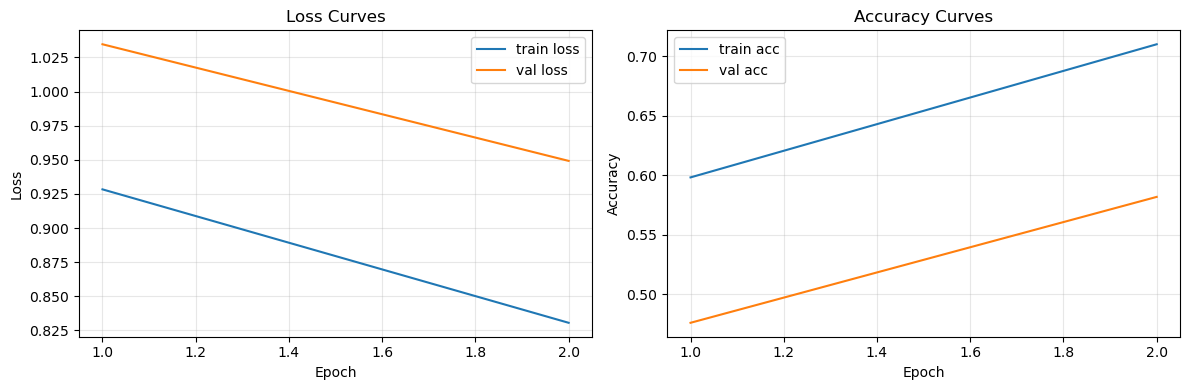

In [7]:
# 训练参数
learning_rate = 1e-4
epochs = 2

# 损失函数与优化器
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 开始训练（使用 val_loader 作为验证集）
history = fit(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    device=device,
)

# 以 JSON 形式保存与展示训练历史
history_json = json.dumps(history, ensure_ascii=False, indent=2)
with open('training_history.json', 'w', encoding='utf-8') as f:
    f.write(history_json)

print('已保存 training_history.json')
print(history_json)

# 绘制训练曲线
plot_training_curves(history)

In [9]:
from sklearn.metrics import accuracy_score, classification_report

# 在测试集上评估保存的最佳模型
best_model = torch.load('best_val_model_pytorch', map_location=device, weights_only=False)
best_model.to(device)

# 1) 复用 evaluate 计算 loss 和 acc
test_loss, test_acc = evaluate(
    model=best_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")

# 2) 收集全部标签与预测，输出 sklearn 评估报告
best_model.eval()
all_targets = []
all_predictions = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device, dtype=torch.float, non_blocking=True)
        targets = targets.to(device, dtype=torch.int64, non_blocking=True)

        outputs = best_model(inputs)
        predictions = outputs.argmax(dim=1)

        all_targets.extend(targets.cpu().numpy().tolist())
        all_predictions.extend(predictions.cpu().numpy().tolist())

print('accuracy_score:', accuracy_score(all_targets, all_predictions))
print(classification_report(all_targets, all_predictions, digits=4))

Test loss: 0.8487
Test acc : 0.6895
accuracy_score: 0.6895073411332875
              precision    recall  f1-score   support

           0     0.6626    0.6908    0.6764     47915
           1     0.7439    0.7160    0.7297     48050
           2     0.6625    0.6588    0.6606     43523

    accuracy                         0.6895    139488
   macro avg     0.6897    0.6885    0.6889    139488
weighted avg     0.6906    0.6895    0.6898    139488

